# Hybrid Simulation: Strong Event Simultaneity


This advanced tutorial demonstrates **strong event simultaneity**: two events that occur at the same real time and must be handled together at the same dense-time instant `(t, micro)`.

In our example, both simultaneous events modify the **same state variable** in the listener component (the velocity `v`). One event inverts the velocity and the other doubles it. These operations commute, so handling them simultaneously is valid: the final result is identical regardless of order.


Strong simultaneity matters because SysSimX uses a tolerance when grouping events that occur "at the same time." When multiple simultaneous events modify the same state, you must ensure one of the following holds:

- The events are **not strongly simultaneous** and the algorithm can reliably determine which occurs first, or
- The event handlers are **commutative** (order does not matter).

Here we intentionally construct two event sources so their zero-crossings occur at the same real time, and we declare the listener's handlers commutative.


## Overview

We build a minimal hybrid system with two event sources and one listener:

- Each source emits a zero-crossing event at the same real time.
- Both events are routed to the same listener.
- The listener applies two velocity updates: `v -> -v` and `v -> 2v`.

Because these updates commute, the Hybrid algorithm can safely treat the events as strongly simultaneous and handle them at the same dense time `(t, micro)`.


## Learning Goals

- Understand what strong event simultaneity means in dense time
- See why simultaneity can be unsafe when multiple events modify the same state
- Use commutativity annotations to allow safe simultaneous handling
- Inspect event times and verify expected behavior


## Prerequisites and Setup

We require the following packages:
- `syssimx`
- `numpy`
- `matplotlib`
- `graphviz` (for system visualization)


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from syssimx.core.base import CoSimComponent
from syssimx.core.events import Event
from syssimx.core.port import PortSpec, PortType
from syssimx.system.connection import EventConnection
from syssimx.system.system import System
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

## Implementation

We reuse a simple linear source and a listener with discrete event handling. The sources generate events via **event indicators** (zero-crossing functions), which requires rollback support for time localization.

The key advanced feature in this tutorial is **commutativity metadata** on the listener: it tells the Hybrid algorithm that the simultaneous updates to velocity are order-independent.


### `HybridSource` Component

The source evolves linearly and emits an event when its indicator crosses zero. We choose initial conditions so that both sources cross zero at the same real time.


In [2]:
class HybridSource(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Event Source")
        self.x0 = x0
        self.v = v
        self.t0 = t0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None) -> None:
        self.outputs["x"].set(self.x, t=t)

    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot, t) -> None:
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

### `HybridListener` Component

The listener handles two event types that both modify velocity `v`:

- `v_invert`: `v -> -v`
- `v_double`: `v -> 2v`

These operations commute: applying either first leads to the same final velocity (`-2v`). We declare this explicitly using commutativity annotations so the algorithm can safely group them as strongly simultaneous.


In [3]:
class HybridListener(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0,v: float = 1.0, t0: float = 0.0,
                 use_event_annotations: bool = False):
        super().__init__(name, group="Listener")
        self.x0 = x0
        self.v = v
        self.t0 = t0

        if use_event_annotations:
            self.event_annotations.update({
                    "v_invert": {"modifies": {"v"}},
                    "v_double": {"modifies": {"v"}},}
            )

            self.event_commutativity.update({("v_invert", "v_double"): True })

        self.input_specs.update({
                "v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in"),
                "v_double": PortSpec(name="v_double", type=PortType.EVENT, direction="in")})
        
        self.output_specs.update({
                "x": PortSpec(name="x", type=PortType.REAL, direction="out"),
                "v": PortSpec(name="v", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None, event_names: list | None = None) -> None:
        self.outputs["x"].set(self.x, t=t)
        self.outputs["v"].set(self.v, t=t)

    def get_state(self):
        return self.snapshot_state()

    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot, t):
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def _handle_events_internal(self, event_names, t):
        v_invert_events = set(["Trigger_1", "Trigger_2", "v_invert"])
        v_double_events = set(["v_double"])

        if v_invert_events.intersection(event_names):
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from {-self.v} to {self.v}")
        elif v_double_events.intersection(event_names):
            self.t0 = t
            self.x0 = self.x
            self.v = 2.0 * self.v
            print(f"{self.name} handled event at t={t:.4f}: v doubled from {self.v / 2.0} to {self.v}")

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}

### Instantiation of Components

We create two similar event sources with mirrored initial conditions so their events occur at the same real time. The listener starts with a positive velocity to make the discrete updates easy to see.


In [4]:
src_comp_1 = HybridSource(name="Source_1", x0=2 / 3, v=-1)
src_comp_2 = HybridSource(name="Source_2", x0=-2 / 3, v=1)
listener_comp = HybridListener(name="Listener", x0=0.0, v=3.0)

components = [src_comp_1, src_comp_2, listener_comp]

### Defining Event Connections

We register zero-crossing event indicators on both sources and connect each event to the listener using `EventConnection`.


In [5]:
def event_indicator_zero_crossing(comp: HybridSource) -> float:
    return comp.x

In [6]:
src_comp_1.add_event_indicator(
    name="v_invert", func=event_indicator_zero_crossing, direction=-1
)
src_comp_2.add_event_indicator(
    name="v_double", func=event_indicator_zero_crossing, direction=1
)

The `EventConnection` objects use event names as ports. SysSimX automatically subscribes the listener to the corresponding source events during `add_event_connection`.


In [7]:
connection_1 = EventConnection(
    src_comp=src_comp_1.name,
    src_port="v_invert",
    dst_comp=listener_comp.name,
    dst_port="v_invert"
)

connection_2 = EventConnection(
    src_comp=src_comp_2.name,
    src_port="v_double",
    dst_comp=listener_comp.name,
    dst_port="v_double"
)

event_connections = [connection_1, connection_2]

### Creating the System

We assemble the system, add the event connections, and initialize. During initialization, SysSimX detects event-capable components and selects the Hybrid algorithm automatically.


In [8]:
system = System(name="Hybrid System - Event Commutativity")

for comp in components:
    system.add_component(comp)

for ev_conn in event_connections:
    system.add_event_connection(ev_conn)

system.initialize(t0=0.0)
system.algorithm.verbose = True
system.algorithm.record_internal_steps = True

### Visualizing the System Graph

The system graph shows both event sources routed to the same listener. In this configuration, the two events are intentionally simultaneous.


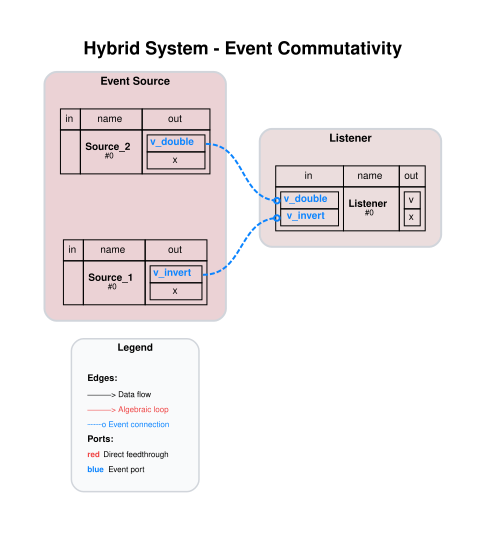

In [9]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [10]:
print("Component Classification:")
for classification, components in system.classify_components().items():
    print(f" - {classification}: {[component.name for component in components]}")
print(f"\nUsing Algorithm: {system.algorithm.name}\n")


Component Classification:
 - event_sources: ['Source_1', 'Source_2']
 - event_listeners: ['Listener']
 - continuous_only: []

Using Algorithm: Hybrid-Algorithm



### Running the Simulation

We simulate with a fixed macro step. Even though the communication grid is coarse, the Hybrid algorithm localizes the event time and dispatches both events at the same dense time instant.


In [11]:
print("Starting hybrid co-simulation...\n")
system.run(t0=0.0, tf=1.0, dt=0.05)

Starting hybrid co-simulation...

[Hybrid] Time: 0.7000 s
[Hybrid] Events detected in interval [0.65000000, 0.70000000]
[Hybrid] Crossings: [('Source_1', 'v_invert'), ('Source_2', 'v_double')]
[Hybrid] Starting Event Localization ...
[Hybrid] Initial Indicators at Left (t=0.65000000): {'Source_1': {'v_invert': 0.016666666666666607}, 'Source_2': {'v_double': -0.016666666666666607}}
[Hybrid] Initial Indicators at Right (t=0.70000000): {'Source_1': {'v_invert': -0.03333333333333344}, 'Source_2': {'v_double': 0.03333333333333344}}
[Hybrid] Entering Bisection Loop ...
[Hybrid] Iteration 1: Interval = [0.65000000, 0.70000000], Mid = 0.67500000

[Hybrid] Indicators at Mid (t=0.67500000): {'Source_1': {'v_invert': -0.008333333333333415}, 'Source_2': {'v_double': 0.008333333333333415}}
[Hybrid] Events in [left, mid]: [('Source_1', 'v_invert'), ('Source_2', 'v_double')]
[Hybrid] Iteration 2: Interval = [0.65000000, 0.67500000], Mid = 0.66250000

[Hybrid] Indicators at Mid (t=0.66250000): {'Sourc

### Retrieving History

We extract source trajectories, listener trajectories, and event times from the system history.


In [12]:
time_src_1, data_src_1 = src_comp_1.get_history_arrays()
x_src_1 = data_src_1["x"]

time_src_2, data_src_2 = src_comp_2.get_history_arrays()
x_src_2 = data_src_2["x"]

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener["x"]

event_history = system.history.get_all_event_histories()
trigger_times_1 = event_history.get((src_comp_1.name, "v_invert"), [])
trigger_times_2 = event_history.get((src_comp_2.name, "v_double"), [])

trigger_time_1 = trigger_times_1[0].t
trigger_time_2 = trigger_times_2[0].t

### Visualizing the Results

The plots show the simultaneous event time and the listener's discrete velocity update. Because the updates commute, the final state is well-defined even under strong simultaneity.


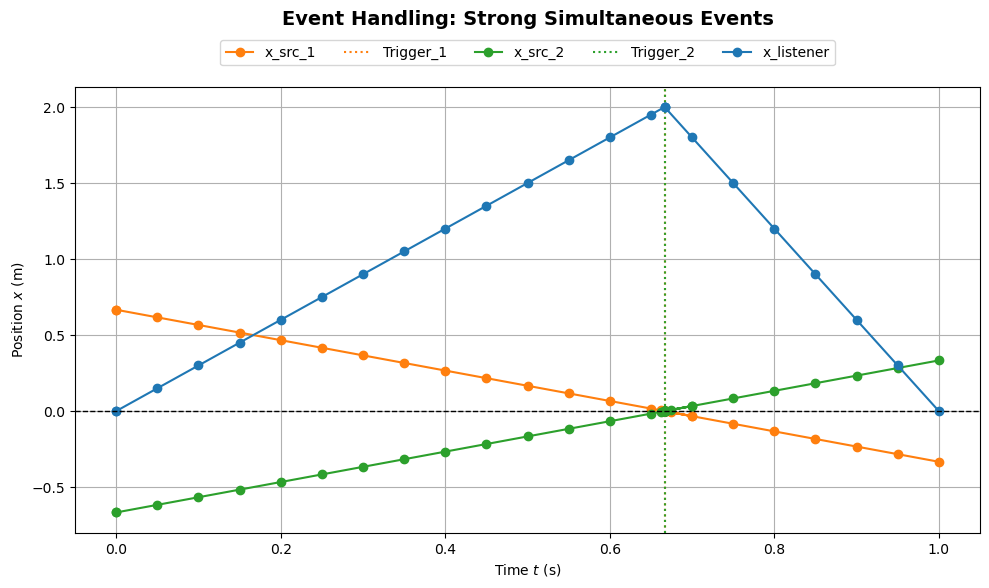

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(time_src_1, x_src_1, label="x_src_1", color="tab:orange", marker="o", linestyle="-")
plt.axvline(trigger_time_1, color="tab:orange", linestyle=":", label="Trigger_1")
plt.plot(time_src_2, x_src_2, label="x_src_2", color="tab:green", marker="o", linestyle="-")
plt.axvline(trigger_time_2, color="tab:green", linestyle=":", label="Trigger_2")
plt.plot(time_listener, x_listener, label="x_listener", color="tab:blue", marker="o", linestyle="-")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Event Handling: Strong Simultaneous Events", fontsize=14, fontweight="bold", y=1.12)
plt.xlabel("Time $t$ (s)")
plt.ylabel("Position $x$ (m)")
plt.grid()
plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.show()

The figure shows the zero-crossing of both event sources occurring at the same real time $t_\text{e} \approx 0.66667 \, \mathrm{s}$.

The inversion and doubling of velocity occur simultaneously, resulting in a final velocity of `-2v_0 = -6.0 m/s` as expected.

## Conclusion

This tutorial shows how to handle strong event simultaneity in hybrid simulations using SysSimX. Verifying commutative event handlers for the modification of the same state variable  is crucial for maintaining simulation correctness in complex hybrid systems.

If the operations do not commute, one must ensure a well-defined order of execution to avoid ambiguity in the final state.